In [1]:
import re
import json
import hashlib
import functools
import random

import numpy as np
import pandas as pd
import scipy.special as ss

import tqdm.notebook as tn

import tensorboardX as tb

from scipy.spatial.distance import cosine

import matplotlib.pyplot as pl
import seaborn as sns

### Tracks

In [2]:
tracks_data = pd.read_json("/Users/n.anokhin/Projects/recsys-course/sim/data/tracks.json", lines=True)

tracks_data.head(3)

FileNotFoundError: File /Users/n.anokhin/Projects/recsys-course/sim/data/tracks.json does not exist

In [9]:
embeddings = np.load("/Users/n.anokhin/Projects/recsys-course/sim/data/embeddings.raw.npy")

embeddings = embeddings - embeddings.mean(axis=0)
embeddings /= np.sqrt((embeddings * embeddings).sum(axis=1))[:, np.newaxis]
embeddings = embeddings.astype(np.float16)

np.save("/Users/n.anokhin/Projects/recsys-course/sim/data/embeddings.npy", embeddings)

embeddings.shape

(16198, 4096)

In [15]:
def normalize(text):
    return text.replace("\n", "")


def trim_values(column):
    value_counts = column.value_counts()
    top = set(value_counts[:20].index.tolist())
    return column.map(lambda v: v if v in top else 'other')


meta_columns = ["artist", "title", "year", "mood", "artist_country", "artist_genre"]

meta = tracks_data[meta_columns].copy()
meta["title"] = meta["title"].map(normalize)
meta["artist"] = meta["artist"].map(normalize)
meta["mood"] = trim_values(meta["mood"].map(normalize))
meta["artist_country"] = trim_values(meta["artist_country"].map(normalize))
meta["artist_genre"] = trim_values(meta["artist_genre"].map(normalize))


writer = tb.SummaryWriter(comment='llm_tracks_embeddings', log_dir="/Users/n.anokhin/Desktop/tb")
writer.add_embedding(embeddings, metadata=list(meta[meta_columns].itertuples(index=False, name=None)), tag="llm", metadata_header=meta_columns)
writer.close()

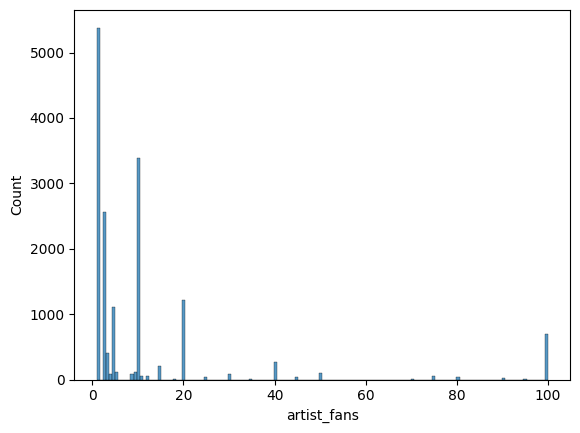

In [16]:
figure, ax = pl.subplots()
sns.histplot(tracks_data["artist_fans"], ax=ax)
pass

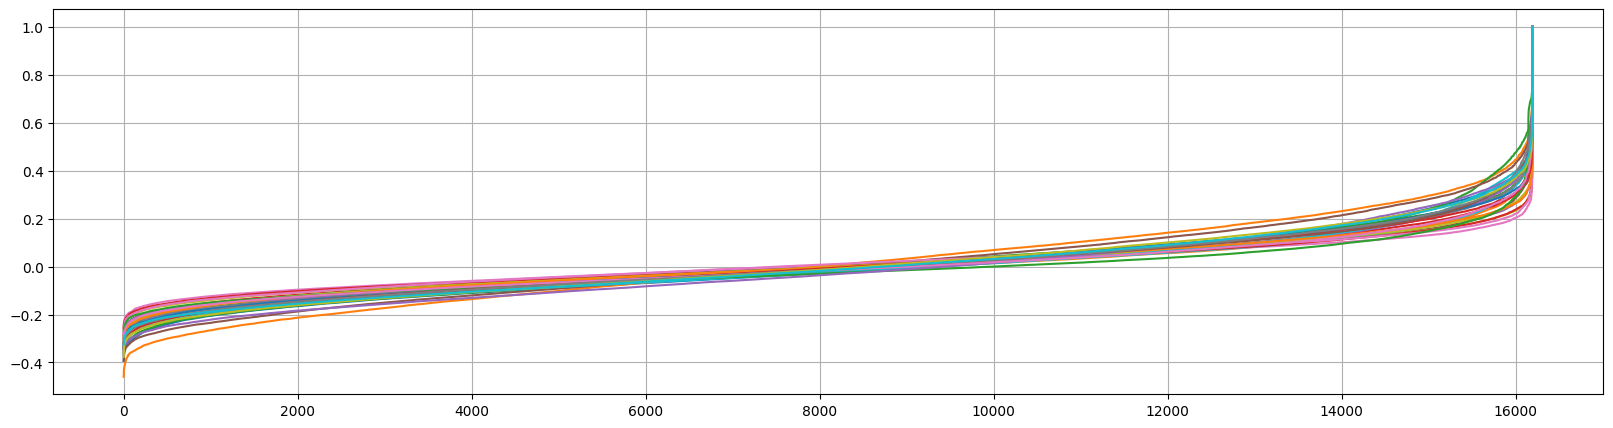

In [17]:
n = 30
sample_tracks = np.random.choice(np.arange(embeddings.shape[0]), n)

dots = np.dot(embeddings[sample_tracks], embeddings.T)
x = np.arange(embeddings.shape[0])

fig, ax = pl.subplots(figsize=(20, 5))

for j in range(n):
    y = np.sort(dots[j])
    ax.plot(x, y)
    
ax.grid()

pass

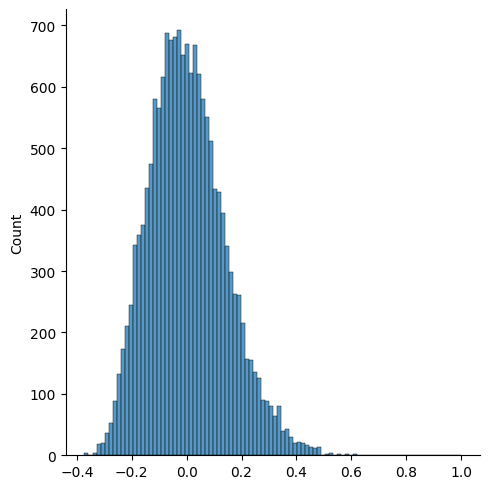

In [25]:
sns.displot(dots[7])

In [7]:
tracks_data["embedding"] = embeddings.tolist()

<Axes: xlabel='embedding', ylabel='Count'>

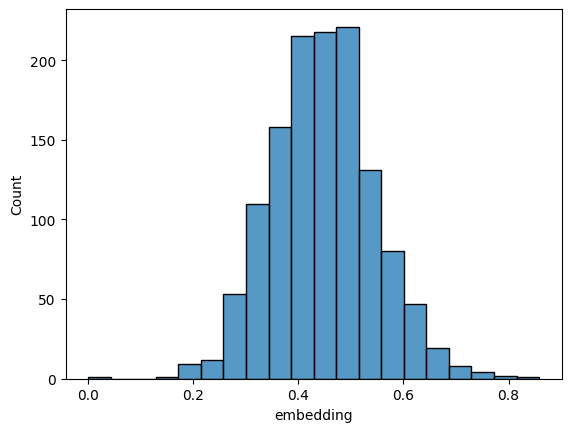

In [8]:
def mean_similarity(embeddings):
    if len(embeddings) < 2:
        return 0
    e = np.array(embeddings.tolist())
    pairs = np.matmul(e, e.T)[np.triu_indices(len(embeddings), k=1)]
    return np.mean(pairs)


artist_means = tracks_data.groupby("artist")["embedding"].agg(mean_similarity)
sns.histplot(artist_means, bins=20)

<Axes: xlabel='embedding', ylabel='Count'>

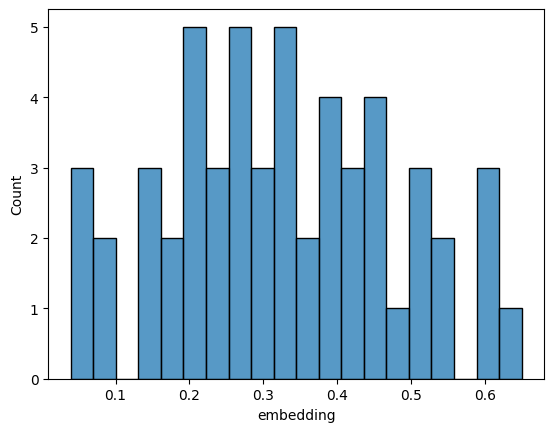

In [9]:
genre_means = tracks_data.groupby("artist_genre")["embedding"].agg(mean_similarity)
sns.histplot(genre_means, bins=20)

In [10]:
mean_similarity(tracks_data["embedding"])

np.float64(0.0008347083271139493)

### Users

In [31]:
users = pd.read_json("/Users/n.anokhin/Projects/recsys-course/sim/data/users.json", lines=True)
# users_1 = pd.read_json("/Users/n.anokhin/Projects/recsys-course/sim/data/users.1.json", lines=True)
# users_2 = pd.read_json("/Users/n.anokhin/Projects/recsys-course/sim/data/users.2.json", lines=True)

# users = pd.concat([users_1, users_2], axis=0).reset_index().drop("index", axis=1)
# users["user"] = users.index.values

users.describe()

,user,consume_bias,consume_sharpness,openness
count,10000.00000,10000.000000,10000.000000,10000.000000
mean,4999.50000,0.250293,9.542755,0.508006
std,2886.89568,0.144917,3.170892,0.143735
min,0.00000,0.000005,4.001018,0.250004
25%,2499.75000,0.124253,6.840009,0.384327
50%,4999.50000,0.249190,9.577032,0.512052
75%,7499.25000,0.375655,12.278812,0.631119
max,9999.00000,0.499976,14.999205,0.749941


In [13]:
users_sample = users.sample(5)
users_sample

,user,interests,consume_bias,consume_sharpness,openness
1433,1433,"[1459, 97, 741]",0.384093,14.164030,0.457695
8164,8164,"[10859, 637, 8344, 1258, 8100]",0.199935,14.567077,0.638099
2542,2542,"[582, 6630, 1652]",0.236860,6.986953,0.553993
8045,8045,"[208, 1227, 7787]",0.361257,9.371344,0.613529
6584,6584,"[9500, 1363, 1618]",0.526722,8.564692,0.278923


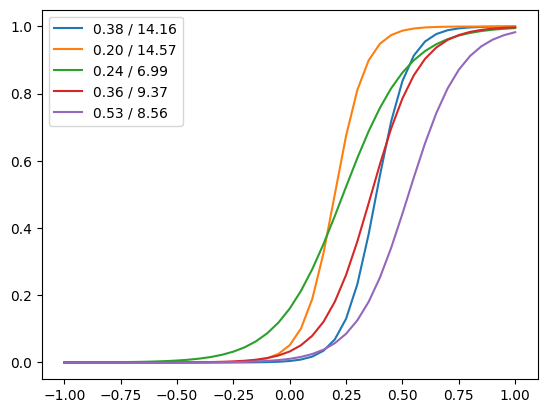

In [14]:
scores = np.linspace(-1, 1, 41)

figure, ax = pl.subplots()

for index, user in users_sample.iterrows():
    times = ss.expit((scores - user["consume_bias"]) * user["consume_sharpness"])
    ax.plot(scores, times, label=f"{user['consume_bias']:.2f} / {user['consume_sharpness']:.2f}")
    

ax.legend()

In [16]:
tracks_data[tracks_data["track"].isin(users_sample.iloc[1]["interests"])]

,title,alternative_title,artist,alternative_artist,genres,year,mood,summary,artist_id,artist_country,artist_genres,artist_genre,artist_fans,track,embedding
637,Proud Mary,None,Tina Turner,None,"[Rock, Soul]",1971,Energetic,The song tells the story of a woman who leaves...,65,Germany,"[Rock, Blues, Soul, Pop, R&B, Funk, Disco]",Rock,100.0,637,"[0.027029061644730727, -0.0024439574858530866,..."
1258,Like Toy Soldiers,None,Eminem,None,"[Hip Hop, Rap]",2004,Sad,The song's lyrics describe the effects of viol...,128,USA,[Hip-Hop / Rap],Hip-Hop / Rap,100.0,1258,"[-0.01732074299023916, 0.005379799183312851, 0..."
8100,The Search,None,NF,None,"[Hip-Hop/Rap, Christian Hip Hop]",2019,Melancholic,The Search is the third studio album by Americ...,240,USA,"[Hip-Hop, Rap, Christian Hip Hop]",Hip-Hop / Rap,10.0,8100,"[-0.010962505012380051, 0.010298108342005431, ..."
8344,Family Portrait,None,P!nk,None,"[Pop, Rock]",2002,Angry,The song tells the story of a girl who has mov...,217,USA,"[Pop, Rock, Electronic / Dance]",Pop,75.0,8344,"[0.032238793663562616, -0.009189850925241098, ..."
10859,A los árboles,None,Joaquín Rodrigo,None,"[Classical, Guitar Music]",1949,Melancholic,A los árboles (To the Trees) is a piece for gu...,578,Spain,"[Classical, Instrumental]",Classical,1.5,10859,"[-0.0006844425394254402, -0.012131753248383392..."


In [23]:
artist_stats = tracks_data.loc[
    [
        item for sublist in 
        users["interests"].values.tolist() 
        for item in sublist
    ]
].groupby("artist").agg({"track": "size", "artist_fans": "max"})

<Axes: xlabel='track', ylabel='Count'>

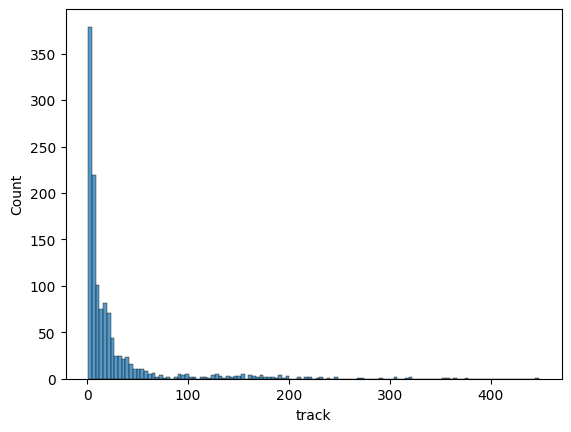

In [24]:
sns.histplot(artist_stats["track"])

<Axes: xlabel='artist_fans', ylabel='track'>

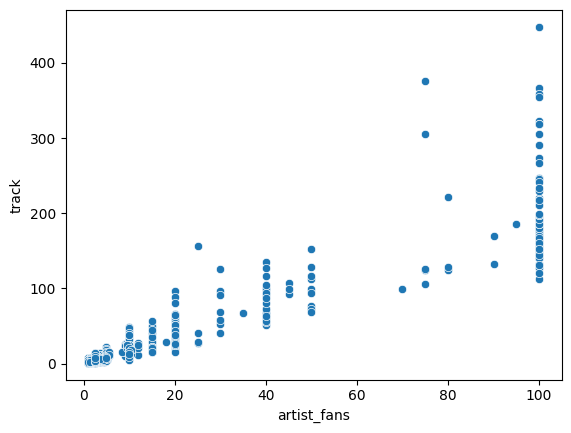

In [25]:
sns.scatterplot(artist_stats, x="artist_fans", y="track")

In [28]:
users.to_json("/Users/n.anokhin/Projects/recsys-course/sim/data/users.json", orient="records", lines=True)

In [32]:
# users["consume_bias"] = users["consume_bias"] - 0.1
# users.to_json("/Users/n.anokhin/Projects/recsys-course/sim/data/users.json", orient="records", lines=True)